# Early-Call Validation Study

**Question:** can early-cycle data (<= cycle 100) flip a qualification verdict reliably and with honest confidence?

Dataset: Severson/MATR — 124 LFP/graphite A123 cells (1.1 Ah nominal), cycled to EOL (80% -> 0.88 Ah).

Gate criteria:

| Metric | BUILD | RESCOPE | KILL |
|---|---|---|---|
| Balanced accuracy @ cycle 100 | >= 0.85 | 0.75–0.85 | ~ chance |
| ECE | <= 0.10 | 0.10–0.20 | > 0.20 |

This notebook contains **two evaluations, in order**:
1. the pre-registered gate run (CalibratedClassifierCV) — first shot, verdict **RESCOPE** (ECE 0.105);
2. a disclosed hardening iteration (OOF calibration, selected by nested CV on train only) prompted by that miss.

Requires the three raw `.mat` batch files in `../data/` (see src/data.py for download URLs).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import build_dataset
from src.labels import make_labels
from src.features import featurize, FEATURE_NAMES
from src.split import canonical_split, report_balance
from src.model import make_model, EarlyVerdictModel
from src.calibration import (oof_calibrated_probs, ensemble_probs,
                             cvap_predict, abstain_call)
from src.gate import (fit_and_evaluate, stabilization_sweep, decide,
                      reliability_diagram, stabilization_plot,
                      expected_calibration_error, CUTOFFS)

DATA_DIR = str(pathlib.Path().resolve().parent / 'data')
FIG_DIR = pathlib.Path().resolve().parent / 'figures'
FIG_DIR.mkdir(exist_ok=True)
np.random.seed(0)

## 1. Load data (canonical exclusions + carry-over merge applied)

In [2]:
bat_dict = build_dataset(DATA_DIR)
print(f"{len(bat_dict)} cells")

124 cells


### Verify structure of one cell (schema check before any feature code)

In [3]:
cell = bat_dict['b1c43']
print('top-level keys:  ', list(cell.keys()))
print('summary keys:    ', list(cell['summary'].keys()))
print('summary lengths: ', {k: len(v) for k, v in cell['summary'].items()})
print('n cycle entries kept (slim, <=105):', len(cell['cycles']))
print('cycle "10" keys: ', list(cell['cycles']['10'].keys()))
print('Qdlin shape @10: ', cell['cycles']['10']['Qdlin'].shape)
print('charge policy:   ', cell['charge_policy'])
print('cycle_life (computed / stored):', cell['cycle_life'], '/', cell['cycle_life_stored'])

top-level keys:   ['cycle_life_stored', 'charge_policy', 'summary', 'cycles', 'cycle_life']
summary keys:     ['IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax', 'chargetime', 'cycle']
summary lengths:  {'IR': 650, 'QC': 650, 'QD': 650, 'Tavg': 650, 'Tmin': 650, 'Tmax': 650, 'chargetime': 650, 'cycle': 650}
n cycle entries kept (slim, <=105): 106
cycle "10" keys:  ['Qdlin']
Qdlin shape @10:  (1000,)
charge policy:    8C(25%)-3.6C
cycle_life (computed / stored): 651.0 / 651.0


### Cycle-life sanity check: computed first-crossing vs value stored in the .mat

In [4]:
rows = []
for k, c in bat_dict.items():
    rows.append({'cell': k, 'computed': c['cycle_life'], 'stored': c['cycle_life_stored'],
                 'diff': c['cycle_life'] - c['cycle_life_stored']})
cl = pd.DataFrame(rows).set_index('cell')
print('|computed - stored| max:', cl['diff'].abs().max(), ' cells >5 off:', int((cl['diff'].abs() > 5).sum()))

|computed - stored| max: 2.0  cells >5 off: 0


## 2. Labels — spec threshold T = 700 cycles

In [5]:
labels, T = make_labels(bat_dict, threshold=700)
lives = np.array([c['cycle_life'] for c in bat_dict.values()])
print(f"cycle life: min={lives.min():.0f} median={np.median(lives):.0f} max={lives.max():.0f}")

threshold T=700: pass=70 fail=54 (pass rate 0.56)
cycle life: min=148 median=736 max=2237


## 3. Canonical split (paper's train / primary-test / secondary-test)

In [6]:
train_keys, primary_keys, secondary_keys = canonical_split(bat_dict.keys())
report_balance('train', train_keys, labels)
report_balance('primary test', primary_keys, labels)
report_balance('secondary test', secondary_keys, labels)
report_balance('combined test', primary_keys + secondary_keys, labels)
eval_sets = {'primary': primary_keys, 'secondary': secondary_keys,
             'combined': primary_keys + secondary_keys}

train            n= 41  pass= 17  fail= 24  pass rate=0.41
primary test     n= 43  pass= 15  fail= 28  pass rate=0.35
secondary test   n= 40  pass= 38  fail=  2  pass rate=0.95
combined test    n= 83  pass= 53  fail= 30  pass rate=0.64


## 4. Pre-registered gate run @ cycle 100

Features: `log10 var/|min|/|mean|` of DeltaQ(V) = Qdlin(100) - Qdlin(10), capacity-fade slope (cycles 2–100), QD @ cycle 2, avg charge time (first 5 cycles), IR @ cycle 2.
Model: logistic regression + `CalibratedClassifierCV` (isotonic — chosen over sigmoid by nested CV on train: 0.085 vs 0.198), standardized on train only.

This is the first-shot protocol; its result is the official gate verdict.

In [7]:
res_prereg = fit_and_evaluate(bat_dict, labels, train_keys, eval_sets, cutoff=100,
                              model_factory=make_model)
print(f"{'eval set':<12s} {'balanced acc':>14s} {'ECE':>8s}")
for name in ['primary', 'secondary', 'combined']:
    r = res_prereg[name]
    print(f"{name:<12s} {r['balanced_acc']:>14.3f} {r['ece']:>8.3f}")
acc_pre, ece_pre = res_prereg['combined']['balanced_acc'], res_prereg['combined']['ece']
print(f"\npre-registered gate: acc={acc_pre:.3f} ECE={ece_pre:.3f} -> {decide(acc_pre, ece_pre)}")

eval set       balanced acc      ECE
primary               0.895    0.094
secondary             1.000    0.134
combined              0.924    0.105

pre-registered gate: acc=0.924 ECE=0.105 -> RESCOPE


## 5. Hardening iteration (disclosed): calibration bake-off

The pre-registered run failed only on calibration, so this pass compares calibrators.
**Selection uses the 41 training cells only** (5-fold x 10-repeat nested CV, criterion = ECE;
ties within 0.01 broken by lower variance, then simpler method). Test sets are untouched
by the selection; because this iteration was motivated by the first test evaluation, it is
labeled adaptive and the winner needs revalidation on fresh data in P1.

In [8]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

X_tr_100 = None  # set below per cutoff; selection runs at cutoff 100
feats100 = featurize(bat_dict, cutoff=100)
X_tr = feats100.loc[train_keys].values
y_tr = np.array([labels[k] for k in train_keys])

METHODS = {  # order = simplicity ranking for tie-breaks
    'sigmoid':       lambda Xa, ya, Xb, seed: oof_calibrated_probs(Xa, ya, Xb, 'sigmoid', seed=seed),
    'beta':          lambda Xa, ya, Xb, seed: oof_calibrated_probs(Xa, ya, Xb, 'beta', seed=seed),
    'isotonic':      lambda Xa, ya, Xb, seed: oof_calibrated_probs(Xa, ya, Xb, 'isotonic', seed=seed),
    'beta-ensemble': lambda Xa, ya, Xb, seed: ensemble_probs(Xa, ya, Xb, 'beta', n_seeds=10),
    'iso-ensemble':  lambda Xa, ya, Xb, seed: ensemble_probs(Xa, ya, Xb, 'isotonic', n_seeds=10),
}

stats = {}
for name, fn in METHODS.items():
    eces = []
    for rep in range(10):
        ps, ys = [], []
        for tr, va in StratifiedKFold(5, shuffle=True, random_state=rep).split(X_tr, y_tr):
            ps.append(fn(X_tr[tr], y_tr[tr], X_tr[va], rep)); ys.append(y_tr[va])
        eces.append(expected_calibration_error(np.hstack(ys), np.hstack(ps)))
    stats[name] = (float(np.mean(eces)), float(np.std(eces)))
    print(f"  {name:<14s} ECE={stats[name][0]:.3f} +-{stats[name][1]:.3f}")

best_mean = min(m for m, s in stats.values())
tied = [n for n, (m, s) in stats.items() if m - best_mean < 0.01]
WINNER = min(tied, key=lambda n: (round(stats[n][1], 3), list(METHODS).index(n)))
print(f"tied within 0.01: {tied}")
print(f"selected (variance, then simplicity): {WINNER}")

  sigmoid        ECE=0.098 +-0.005


  beta           ECE=0.050 +-0.012


  isotonic       ECE=0.050 +-0.010


  beta-ensemble  ECE=0.048 +-0.010


  iso-ensemble   ECE=0.048 +-0.014
tied within 0.01: ['beta', 'isotonic', 'beta-ensemble', 'iso-ensemble']
selected (variance, then simplicity): isotonic


### Hardened gate metrics @ cycle 100 (`EarlyVerdictModel`, OOF-isotonic)

In [9]:
res100 = fit_and_evaluate(bat_dict, labels, train_keys, eval_sets, cutoff=100,
                          model_factory=EarlyVerdictModel)
print(f"{'eval set':<12s} {'balanced acc':>14s} {'ECE':>8s}")
for name in ['primary', 'secondary', 'combined']:
    r = res100[name]
    print(f"{name:<12s} {r['balanced_acc']:>14.3f} {r['ece']:>8.3f}")

# seed sensitivity of the final model (CV fold assignment is the only randomness)
X_te = feats100.loc[eval_sets['combined']].values
y_te = np.array([labels[k] for k in eval_sets['combined']])
eces = []
for seed in range(10):
    m = EarlyVerdictModel(seed=seed).fit(X_tr, y_tr)
    eces.append(expected_calibration_error(y_te, m.predict_proba(X_te)[:, 1]))
print(f"\ncombined-test ECE across 10 CV seeds: {np.mean(eces):.3f} +-{np.std(eces):.3f} (max {np.max(eces):.3f})")

eval set       balanced acc      ECE
primary               0.913    0.081
secondary             1.000    0.056
combined              0.941    0.054

combined-test ECE across 10 CV seeds: 0.036 +-0.007 (max 0.054)


## 6. Reliability diagram (combined test, hardened model)

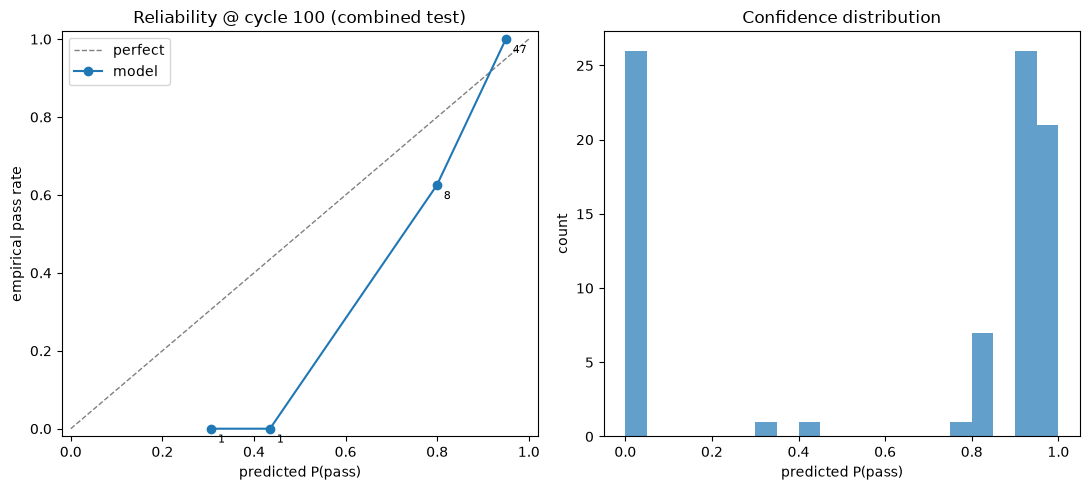

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
reliability_diagram(res100['combined']['y'], res100['combined']['p'], ax=axes[0],
                    title='Reliability @ cycle 100 (combined test)')
axes[1].hist(res100['combined']['p'], bins=20, color='tab:blue', alpha=0.7)
axes[1].set_xlabel('predicted P(pass)'); axes[1].set_ylabel('count')
axes[1].set_title('Confidence distribution')
plt.tight_layout()
plt.savefig(FIG_DIR / 'reliability_cycle100.png', dpi=150)
plt.show()

## 7. Stabilization sweep — the evidence for the "call it now" feature

Refit and evaluate (hardened model) with data cut off at cycles {40, 50, 60, 80, 100}.

In [11]:
sweep = stabilization_sweep(bat_dict, labels, train_keys, eval_sets, cutoffs=CUTOFFS,
                            model_factory=EarlyVerdictModel)
print(f"{'cutoff':>7s} {'prim acc':>9s} {'prim ECE':>9s} {'sec acc':>9s} {'sec ECE':>9s} {'comb acc':>9s} {'comb ECE':>9s}")
for c in CUTOFFS:
    r = sweep[c]
    print(f"{c:>7d} {r['primary']['balanced_acc']:>9.3f} {r['primary']['ece']:>9.3f} "
          f"{r['secondary']['balanced_acc']:>9.3f} {r['secondary']['ece']:>9.3f} "
          f"{r['combined']['balanced_acc']:>9.3f} {r['combined']['ece']:>9.3f}")

 cutoff  prim acc  prim ECE   sec acc   sec ECE  comb acc  comb ECE
     40     0.862     0.071     0.737     0.125     0.888     0.056
     50     0.898     0.029     0.987     0.015     0.938     0.008
     60     0.826     0.123     0.500     0.187     0.848     0.154
     80     0.862     0.080     0.737     0.103     0.888     0.076
    100     0.913     0.081     1.000     0.056     0.941     0.054


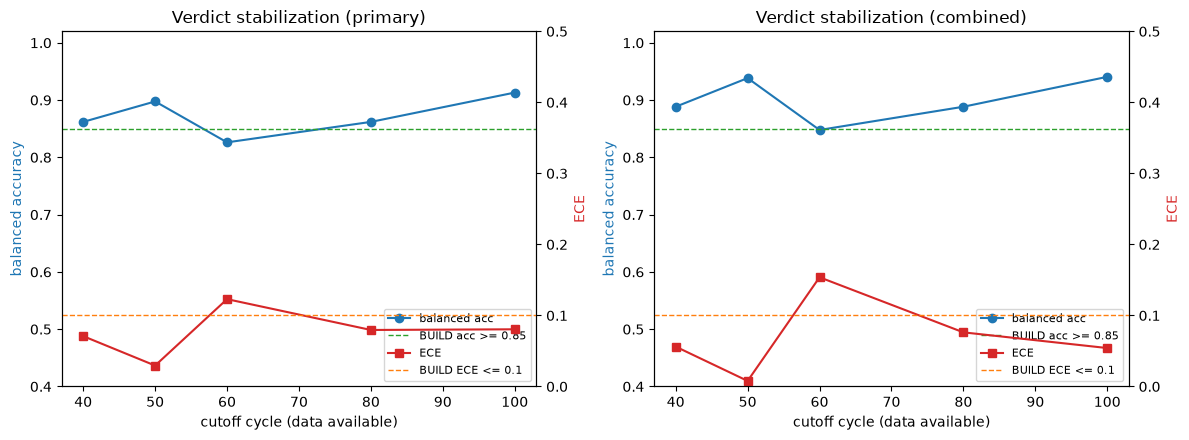

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
stabilization_plot(sweep, 'primary', ax=axes[0])
stabilization_plot(sweep, 'combined', ax=axes[1])
plt.tight_layout()
plt.savefig(FIG_DIR / 'stabilization.png', dpi=150)
plt.show()

## 8. Venn-ABERS intervals + abstain — the rescoped product

Cross Venn-ABERS gives each cell a probability interval [p0, p1] with distribution-free
validity. Verdict rule: **pass** if p0 > 0.5, **fail** if p1 < 0.5, otherwise **keep testing**.
The displayed probability for called cells comes from the hardened point model; CVAP's own
point probability is not well calibrated at this n and is used only for the interval.

In [13]:
kc = eval_sets['combined']
y_c = np.array([labels[k] for k in kc])
rows = []
for cutoff in CUTOFFS:
    f = featurize(bat_dict, cutoff=cutoff)
    Xa, Xb = f.loc[train_keys].values, f.loc[kc].values
    _, p0, p1 = cvap_predict(Xa, y_tr, Xb, seed=0)
    call = abstain_call(p0, p1)
    c = call != -1
    rows.append({'cutoff': cutoff, 'called_frac': c.mean(),
                 'acc_on_called': float(np.mean(call[c] == y_c[c])),
                 'mean_interval_width': float(np.mean(p1 - p0))})
    if cutoff == 100:
        call100, p0_100, p1_100 = call, p0, p1
callable_df = pd.DataFrame(rows).set_index('cutoff')
print(callable_df.round(3))

        called_frac  acc_on_called  mean_interval_width
cutoff                                                 
40            0.759          0.984                0.352
50            0.675          0.982                0.402
60            0.723          1.000                0.375
80            0.747          1.000                0.406
100           0.759          1.000                0.394


In [14]:
abstained = [(k, bat_dict[k]['cycle_life']) for k, c in zip(kc, call100) if c == -1]
print(f"@100: called {int((call100 != -1).sum())}/{len(kc)}, abstained {len(abstained)}")
print('abstained cells (true cycle life, T=%d):' % T)
print('  ', sorted(round(l) for _, l in abstained))

@100: called 63/83, abstained 20
abstained cells (true cycle life, T=700):
   [499, 511, 519, 534, 541, 599, 625, 636, 648, 651, 667, 703, 713, 731, 757, 772, 786, 917, 1002, 1051]


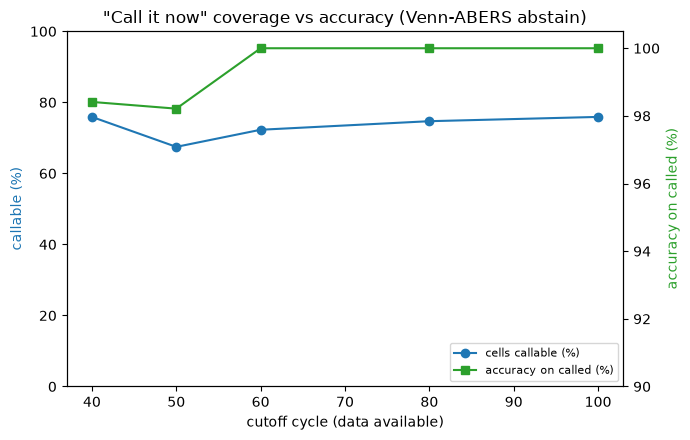

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(callable_df.index, 100 * callable_df['called_frac'], 'o-', color='tab:blue', label='cells callable (%)')
ax.set_xlabel('cutoff cycle (data available)')
ax.set_ylabel('callable (%)', color='tab:blue')
ax.set_ylim(0, 100)
ax2 = ax.twinx()
ax2.plot(callable_df.index, 100 * callable_df['acc_on_called'], 's-', color='tab:green', label='accuracy on called (%)')
ax2.set_ylabel('accuracy on called (%)', color='tab:green')
ax2.set_ylim(90, 100.5)
ax.set_title('"Call it now" coverage vs accuracy (Venn-ABERS abstain)')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'callable_curve.png', dpi=150)
plt.show()

## 9. Where the early call breaks — misclassified cells @ cycle 100 (hardened model)

In [16]:
mis_rows = []
for name in ['primary', 'secondary']:
    r = res100[name]
    for k, yt, yp, p in zip(r['keys'], r['y'], r['yhat'], r['p']):
        if yt != yp:
            mis_rows.append({'cell': k, 'split': name, 'true': int(yt), 'pred': int(yp),
                             'P(pass)': round(float(p), 3),
                             'cycle_life': bat_dict[k]['cycle_life'],
                             'policy': bat_dict[k]['charge_policy']})
mis = pd.DataFrame(mis_rows).sort_values('cycle_life') if mis_rows else pd.DataFrame()
print(f"{len(mis)} misclassified of {len(res100['combined']['y'])} test cells")
display(mis)

4 misclassified of 83 test cells


,cell,split,true,pred,P(pass),cycle_life,policy
0,b1c6,primary,0,1,0.800,636.0,4.8C(80%)-4.8C
1,b1c37,primary,0,1,0.794,648.0,7C(40%)-3C
2,b1c43,primary,0,1,0.800,651.0,8C(25%)-3.6C
3,b2c47,primary,1,0,0.000,713.0,6C(60%)-3C


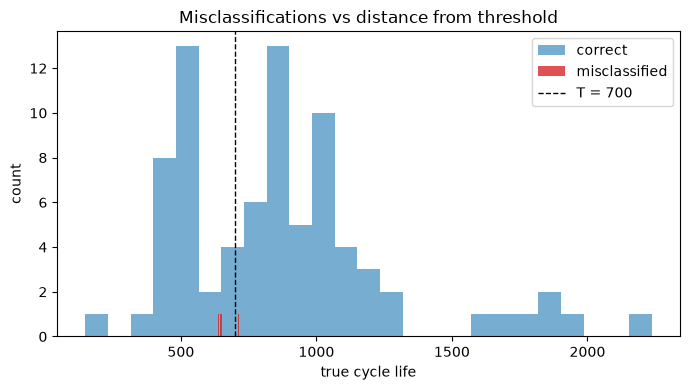

In [17]:
lives_all = {k: bat_dict[k]['cycle_life'] for k in res100['combined']['keys']}
correct = [lives_all[k] for k, yt, yp in zip(res100['combined']['keys'], res100['combined']['y'], res100['combined']['yhat']) if yt == yp]
wrong = [lives_all[k] for k, yt, yp in zip(res100['combined']['keys'], res100['combined']['y'], res100['combined']['yhat']) if yt != yp]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(correct, bins=25, alpha=0.6, label='correct', color='tab:blue')
ax.hist(wrong, bins=25, alpha=0.8, label='misclassified', color='tab:red')
ax.axvline(T, ls='--', color='k', lw=1, label=f'T = {T}')
ax.set_xlabel('true cycle life'); ax.set_ylabel('count')
ax.set_title('Misclassifications vs distance from threshold')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'misclassified_vs_life.png', dpi=150)
plt.show()

## 10. Gate decision

In [18]:
from src.gate import ACC_BUILD, ECE_BUILD

acc_h = res100['combined']['balanced_acc']
ece_h = res100['combined']['ece']

stab_cycle = None
for c in CUTOFFS:
    if all(sweep[cc]['combined']['balanced_acc'] >= ACC_BUILD for cc in CUTOFFS if cc >= c):
        stab_cycle = c
        break

W = 54
print('=' * W)
print(f"{'EARLY-CALL STUDY RESULT':^{W}s}")
print('=' * W)
print(f"{'pre-registered run (first shot):':<40s}")
print(f"{'  balanced accuracy @ cycle 100:':<40s}{acc_pre:>8.3f}")
print(f"{'  ECE @ cycle 100:':<40s}{ece_pre:>8.3f}")
print(f"{'  DECISION (official gate):':<40s}{decide(acc_pre, ece_pre):>8s}")
print('-' * W)
print(f"{'hardened run (adaptive, train-side selection):':<40s}")
print(f"{'  balanced accuracy @ cycle 100:':<40s}{acc_h:>8.3f}")
print(f"{'  ECE @ cycle 100:':<40s}{ece_h:>8.3f}")
print(f"{'  meets gate bars:':<40s}{str(acc_h >= ACC_BUILD and ece_h <= ECE_BUILD):>8s}")
print(f"{'  verdict stabilizes at cycle:':<40s}{str(stab_cycle):>8s}")
print('-' * W)
print(f"{'RECOMMENDATION:':<24s}{'RESCOPE -> BUILD, pending':>30s}")
print(f"{'':<24s}{'P1 revalidation of ECE':>30s}")
print('=' * W)

                 EARLY-CALL STUDY RESULT                  
pre-registered run (first shot):        
  balanced accuracy @ cycle 100:           0.924
  ECE @ cycle 100:                         0.105
  DECISION (official gate):              RESCOPE
------------------------------------------------------
hardened run (adaptive, train-side selection):
  balanced accuracy @ cycle 100:           0.941
  ECE @ cycle 100:                         0.054
  meets gate bars:                          True
  verdict stabilizes at cycle:                80
------------------------------------------------------
RECOMMENDATION:              RESCOPE -> BUILD, pending
                                P1 revalidation of ECE
